In [1]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
import copy

from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Union
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
sns.set_style('whitegrid')

#switch dir and load packages
import os

os.chdir(r'..\..')

from app.dike_components.dike_model import DikeModel
from app.cost_calculator import CostCalculator, DirectCostGroundWork, StructureCosts, InfrastructureCosts
from app.unit_costs_and_surcharges import load_kosten_catalogus
from dev.incremental_costs.utils import get_dimensions_dict_from_df, modified_cost_computation, make_reinforcement_incremental, compute_incremental_volumes, compute_incremental_costs, compute_lcc, lcc_plot



Dit notebook geeft een voorbeeld hoe kosten kunnen worden bepaald uit output files van de Verkenning-2.0-backend
We gebruiken 3 kosteninschattingen van de Scheldestromen casus als voorbeeld.

## Invoerpaden en incrementele versterkingen
In onderstaande cel moet de werkmap met de kostenuitvoer worden geselecteerd, en de filenamen van de verschillende versterkingen. Daarbij kan per file een naam van de maatregel worden opgegeven waarmee later evt. kan worden gecombineerd tot adaptatiepad.

In [2]:
# Path of WJK
working_dir = Path(r"c:\Users\klerk_wj\Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")
# Path of Yida
# working_dir = Path(r"C:\Users\tao\OneDrive - Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")

sns.set_palette("Set2", 12)



## Berekenen van kosten van incrementele versterkingen
Nu gaan we de kosten van incrementele versterkingen bepalen. Deze worden gebaseerd op de met de toolbox bepaalde kosten. 
We hebben dus kosten van bijv huidige situatie naar Grondversterking 2026 en huidige situatie naar Grondversterking 2075.
We gaan nu de kosten berekenen voor Grondversterking 2025 naar Grondversterking 2075, dus alleen de meerkosten.

## Adaptatiepad 1: grondversterking
We kijken eerst puur naar het adaptatiepad voor grondversterking.

In [3]:
## SETTINGS ## 
files = ['ontwerpvariant grond gestacked/kostenoverzicht design grond 1.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 2 aanlegprofiel.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',]

names = ["Grondversterking 2025", "Grondversterking 2075", "Grondversterking 2125"]

alternatives = dict(zip(names, files))

dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)
    print(f"Kosten van beginsituatie naar {name}:")
    print(f"€{cost_summaries[name]['Kosten excl. BTW'].sum():,.0f}")

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
print("Kosten van alle losse alternatieven:")
#add (ruw) to the column names of df_all_costs
df_all_costs.columns = [col + " (ruw)" for col in df_all_costs.columns]

cost_per_increment_summary, cost_per_increment_detailed, dimensions_per_increment = compute_incremental_costs(names, dimensions, dike)

df_all_increments = pd.concat(cost_per_increment_summary.values(), axis=1)
df_all_increments.columns = cost_per_increment_summary.keys()
df_all_increments.columns = [col + " (incrementeel)" for col in df_all_increments.columns]


#merge the incremental costs with the plain costs
df_all_costs_with_increments = pd.concat([df_all_costs, df_all_increments], axis=1)
df_all_costs_with_increments
#add (incrementeel) to the column names of df_all_increments before merging

#add Vastgoedkosten 1300000 for Grondversterking 2025
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 (ruw)'] = 1300000
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2075 (ruw)'] = 1300000 + 100 * (250*3)
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2125 (ruw)'] = 1300000 + 100 * (250*3) + 100 * (250*5)

#add grondaankoop kosten for Grondversterking 2075 and 2125:
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 (incrementeel)'] = 1300000
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2025 to Grondversterking 2075 (incrementeel)'] = 100 * (250*3)
df_all_costs_with_increments.loc['Vastgoedkosten', 'Grondversterking 2075 to Grondversterking 2125 (incrementeel)'] = 100 * (250*5)

print("Kosten per versterking (ruw en incrementeel):")
df_all_costs_with_increments


Kosten van beginsituatie naar Grondversterking 2025:
€1,317,010
Kosten van beginsituatie naar Grondversterking 2075:
€1,630,445
Kosten van beginsituatie naar Grondversterking 2125:
€2,125,449
Kosten van alle losse alternatieven:
Kosten van Grondversterking 2025:
€1,317,010


Incrementele kosten van Grondversterking 2025 naar Grondversterking 2075:
€1,400,548


Incrementele kosten van Grondversterking 2075 naar Grondversterking 2125:
€1,773,155


Kosten per versterking (ruw en incrementeel):


,Grondversterking 2025 (ruw),Grondversterking 2075 (ruw),Grondversterking 2125 (ruw),Grondversterking 2025 (incrementeel),Grondversterking 2025 to Grondversterking 2075 (incrementeel),Grondversterking 2075 to Grondversterking 2125 (incrementeel)
Directe kosten grondwerk,2.890552e+05,4.226210e+05,6.383002e+05,2.890552e+05,313398.468368,470927.830730
Directe kosten constructies,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
Directe kosten infrastructuur,2.900054e+05,3.032242e+05,3.200169e+05,2.900054e+05,303224.166200,320016.907870
Directe niet-benoemde bouwkosten,3.767220e+04,4.300105e+04,5.115070e+04,3.767220e+04,39724.370671,46129.525709
Indirecte bouwkosten,2.170939e+05,2.706388e+05,3.553391e+05,2.170939e+05,231038.346465,294655.498312
Engineeringkosten,1.869504e+05,2.330606e+05,3.060003e+05,1.869504e+05,198958.653566,253742.558787
Overige bijkomende kosten,7.515594e+04,9.369269e+04,1.230152e+05,7.515594e+04,79983.378318,102007.058809
Objectoverstijgende risicoreservering,2.210773e+05,2.642069e+05,3.316270e+05,2.210773e+05,234220.272050,285675.545256
Vastgoedkosten,1.300000e+06,1.375000e+06,1.500000e+06,1.300000e+06,75000.000000,125000.000000


In [4]:
#reorder the lines in the df_all_costs_with_increments dataframe such that Indirecte bouwkosten, engineeringkosten, overige bijkomende kosten en objectoverstijgende risicoreservering are summed to "Indirecte en bijkomende kosten (engineering, risico e.d.)". Keep others the same.
df_all_costs_with_increments.loc['Indirecte en bijkomende kosten (engineering, risico e.d.)'] = df_all_costs_with_increments.loc['Indirecte bouwkosten'] + df_all_costs_with_increments.loc['Engineeringkosten'] + df_all_costs_with_increments.loc['Overige bijkomende kosten'] + df_all_costs_with_increments.loc['Objectoverstijgende risicoreservering']
df_all_costs_with_increments = df_all_costs_with_increments.drop(['Indirecte bouwkosten', 'Engineeringkosten', 'Overige bijkomende kosten', 'Objectoverstijgende risicoreservering'])
#rename "Directe kosten grondwerk", "Directe kosten constructies", "Directe kosten infrastructuur" to "Directe bouwkosten (grondwerk)", "Directe bouwkosten (constructies)", "Directe bouwkosten (infrastructuur)". And Directe niet-bouwkosten to "Directe niet-benoemde bouwkosten" to "Directe bouwkosten (niet-benoemd)" 
df_all_costs_with_increments = df_all_costs_with_increments.rename(index={'Directe kosten grondwerk': 'Directe bouwkosten (grondwerk)', 'Directe kosten constructies': 'Directe bouwkosten (constructies)', 'Directe kosten infrastructuur': 'Directe bouwkosten (infrastructuur)', 'Directe niet-bouwkosten': 'Directe bouwkosten (niet-benoemd)'})
#order the index: Directe kosten, indirecte kosten and then vastgoed
df_all_costs_with_increments = df_all_costs_with_increments.reindex(['Directe bouwkosten (grondwerk)', 'Directe bouwkosten (constructies)', 'Directe bouwkosten (infrastructuur)', 'Directe bouwkosten (niet-benoemd)', 'Indirecte en bijkomende kosten (engineering, risico e.d.)', 'Vastgoedkosten'])

df_all_costs_with_increments

,Grondversterking 2025 (ruw),Grondversterking 2075 (ruw),Grondversterking 2125 (ruw),Grondversterking 2025 (incrementeel),Grondversterking 2025 to Grondversterking 2075 (incrementeel),Grondversterking 2075 to Grondversterking 2125 (incrementeel)
Directe bouwkosten (grondwerk),2.890552e+05,4.226210e+05,6.383002e+05,2.890552e+05,313398.468368,470927.830730
Directe bouwkosten (constructies),0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
Directe bouwkosten (infrastructuur),2.900054e+05,3.032242e+05,3.200169e+05,2.900054e+05,303224.166200,320016.907870
Directe bouwkosten (niet-benoemd),NaN,NaN,NaN,NaN,NaN,NaN
"Indirecte en bijkomende kosten (engineering, risico e.d.)",7.002775e+05,8.615989e+05,1.115982e+06,7.002775e+05,744200.650399,936080.661163
Vastgoedkosten,1.300000e+06,1.375000e+06,1.500000e+06,1.300000e+06,75000.000000,125000.000000


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_39092\136574086.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])


[Text(0, 0, 'Grondversterking 2025'),
 Text(1, 0, 'Grondversterking 2075'),
 Text(2, 0, 'Grondversterking 2125')]

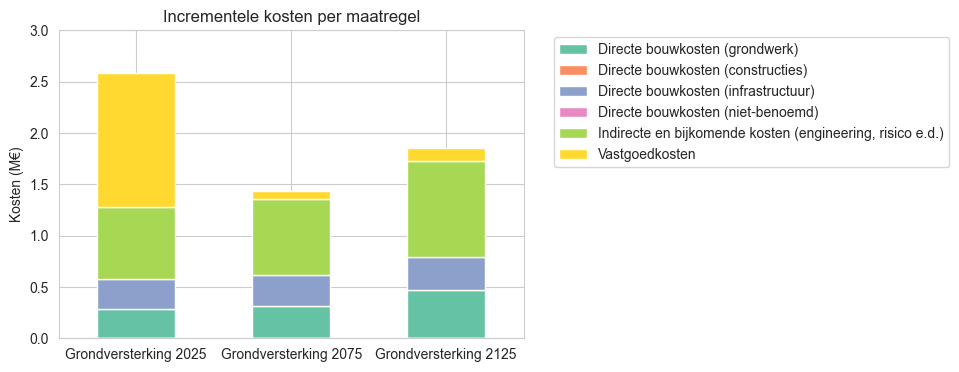

In [5]:
#make a stacked bar plot of all the increment costs per measure
fig, ax = plt.subplots(figsize=(6,4))
increment_costs_only = df_all_costs_with_increments.loc[:, [col for col in df_all_costs_with_increments.columns if '(incrementeel)' in col]]
increment_costs_only.T.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Incrementele kosten per maatregel')
ax.set_ylabel('Kosten (M€)')
ax.set_ylim(0, np.ceil(ax.get_ylim()[1] / 1e6)*1e6)
#make legend outside of the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')


#scale y-axislabels to millions
ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])

#rotate x-axis labels and remove (incrementeel) and everything before "to"from the labels
ax.set_xticklabels([label.get_text().split(' to ')[-1].replace(' (incrementeel)', '') for label in ax.get_xticklabels()], rotation=0, ha='center')
# ax.set_ylim(0, ax.get_ylim()[1] / 1e6)


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_39092\2901974345.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])


[Text(0, 0, 'Grondversterking 2025'),
 Text(1, 0, 'Grondversterking 2075'),
 Text(2, 0, 'Grondversterking 2125')]

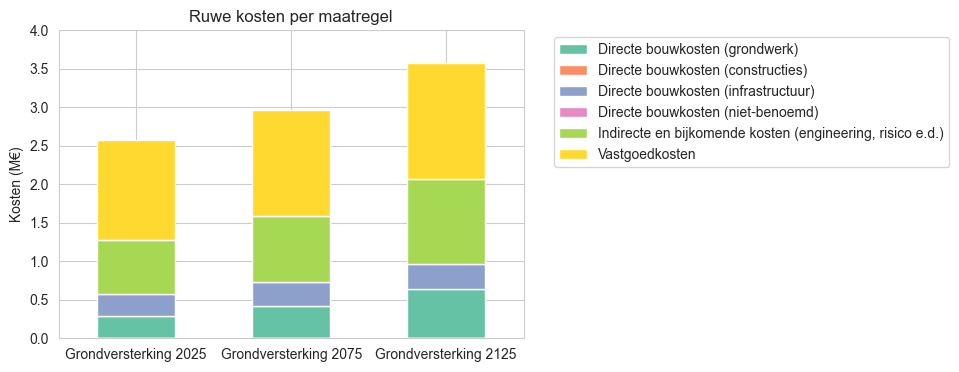

In [6]:
#same plot for (ruw) costs
fig, ax = plt.subplots(figsize=(6,4))
raw_costs_only = df_all_costs_with_increments.loc[:, [col for col in df_all_costs_with_increments.columns if '(ruw)' in col]]
raw_costs_only.T.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Ruwe kosten per maatregel')
ax.set_ylabel('Kosten (M€)')
ax.set_ylim(0, np.ceil(ax.get_ylim()[1] / 1e6)*1e6)
#make legend outside of the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

#scale y-axislabels to millions
ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])
#rotate x-axis labels and remove (ruw) and everything before "to" from the labels
ax.set_xticklabels([label.get_text().split(' to ')[-1].replace(' (ruw)', '') for label in ax.get_xticklabels()], rotation=0, ha='center')


c:\Repositories\Verkenning-2.0-backend\dev\incremental_costs\utils.py:315: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1e6:.1f}" for y in ax.get_yticks()])


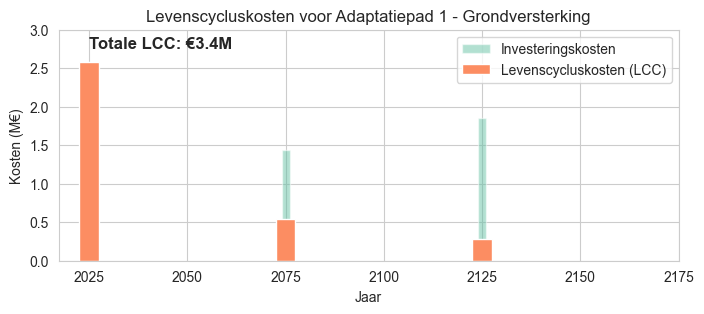

In [ ]:
#LCC computation
#make dict with sum of incremental costs per measure, year, lifespan (50 for soil) in a tuple
incremental_costs_per_measure = {}
for col in increment_costs_only.columns:
    measure_name = col.split(' (incrementeel)')[0]
    #find the year in the measure name 
    year = int(measure_name.split(' ')[-1])
    incremental_costs_per_measure[measure_name] = (increment_costs_only[col].sum(), year, 100)
    # incremental_costs_per_measure[measure_name] = (increment_costs_only[col].sum(), year, 50)

total_horizon = 150
lcc_per_measure = compute_lcc(incremental_costs_per_measure, total_horizon=total_horizon)
lcc_per_measure

undiscounted_costs = [cost for cost, year, lifespan in incremental_costs_per_measure.values()]
lcc_values = [lcc for lcc in lcc_per_measure.values()]
years = [year for cost, year, lifespan in incremental_costs_per_measure.values()]



lcc_plot(undiscounted_costs, lcc_values, years, total_horizon, title='Levenscycluskosten voor Adaptatiepad 1 - Grondversterking')

## Adaptatiepad 2 - constructief

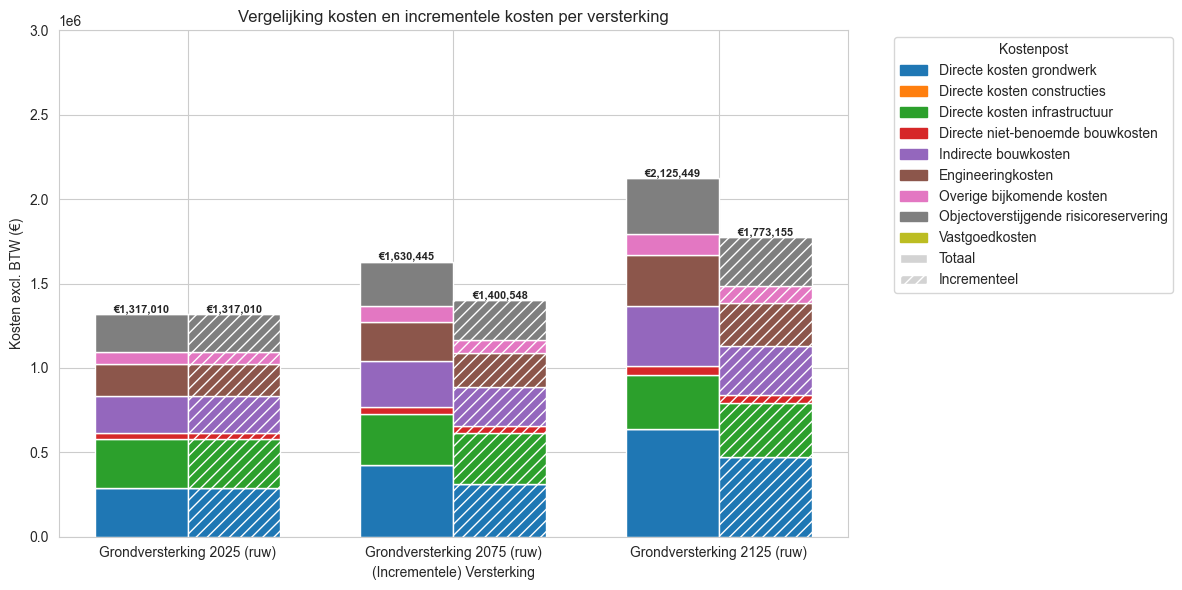

In [8]:
df_costs_T = df_all_costs.T
df_increments_T = df_all_increments.T

categories = df_costs_T.index          # cost categories (x-axis groups)
columns = df_costs_T.columns           # reinforcement variants
n = len(categories)
bar_width = 0.35
x = np.arange(n)

max_val = max(df_costs_T.sum(axis=1).max(), df_increments_T.sum(axis=1).max())
# Round up to nearest 0.5e6 with extra 0.5e6 margin for bar labels
y_max = (math.ceil(max_val / 0.5e6) + 1) * 0.5e6

fig, ax = plt.subplots(figsize=(12, 6))

# Use the same colormap for both stacks
colors = plt.cm.tab10.colors

# Draw stacked bars for df_all_costs (left of each group)
bottoms = np.zeros(n)
for i, col in enumerate(columns):
    values = df_costs_T[col].values
    ax.bar(x - bar_width / 2, values, width=bar_width, bottom=bottoms,
           color=colors[i % len(colors)], label=col)
    bottoms += values

# Add total label on top of each cost bar
for i, total in enumerate(df_costs_T.sum(axis=1)):
    ax.text(x[i] - bar_width / 2, bottoms[i], f"€{total:,.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

# Draw stacked bars for df_all_increments (right of each group)
bottoms = np.zeros(n)
for i, col in enumerate(columns):
    values = df_increments_T[col].values
    ax.bar(x + bar_width / 2, values, width=bar_width, bottom=bottoms,
           color=colors[i % len(colors)], hatch="///")
    bottoms += values

# Add total label on top of each increment bar
for i, total in enumerate(df_increments_T.sum(axis=1)):
    ax.text(x[i] + bar_width / 2, bottoms[i], f"€{total:,.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

# Legend: one entry per column (color), plus a hatch indicator
column_handles = [mpatches.Patch(color=colors[i % len(colors)], label=col)
                  for i, col in enumerate(columns)]
hatch_handles = [
    mpatches.Patch(facecolor="lightgrey", label="Totaal"),
    mpatches.Patch(facecolor="lightgrey", hatch="///", label="Incrementeel"),
]
ax.legend(handles=column_handles + hatch_handles,
          title="Kostenpost", bbox_to_anchor=(1.05, 1), loc="upper left")

ax.set_title("Vergelijking kosten en incrementele kosten per versterking")
ax.set_ylabel("Kosten excl. BTW (€)")
ax.set_xlabel("(Incrementele) Versterking")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0, ha="center")
ax.set_ylim(0, y_max)
plt.tight_layout()
plt.show()